# NEURO 120 Final Project: song vs. speech vs. instrumental music in human ECoG

**Question.** Is the song-vs-music signal in human auditory cortex really concentrated in the seven song-selective electrodes of Norman--Haignere et al. (2022), or is it something any small group of auditory-cortex electrodes could produce?

**What this notebook is.** A thin driver for the analysis modules in `logic/` (and `pipeline.py`). Running it top-to-bottom reproduces every figure and table referenced in the write-up from `results/`.

**Design choices that keep the analysis honest:**

- Cross-validation always groups by stimulus (`StratifiedGroupKFold`), so the same stimulus never appears in both train and test.
- Any feature scaling is fit on training folds only.
- Every random procedure uses the seed in `config.RANDOM_STATE`.
- We report negative results (random-subset control, nonlinear models) alongside the positive ones.

**Dataset at a glance.** 33 electrodes (7 song, 15 speech, 11 music) recording high-frequency activity (HFA) for 49 stimuli (11 song, 17 speech, 21 music) over 0--2 s.


## 1) Setup


In [15]:
import warnings
warnings.filterwarnings("ignore")

import sys
from pathlib import Path

# All analysis modules live inside the `logic/` package. Adding the
# package directory to sys.path keeps the flat `import config` /
# `from decoding import ...` style working inside the notebook without
# having to rewrite every intra-module import elsewhere.
LOGIC_DIR = (Path.cwd() / "logic").resolve()
if str(LOGIC_DIR) not in sys.path:
    sys.path.insert(0, str(LOGIC_DIR))

import numpy as np
import pandas as pd
from IPython.display import Image, display

import config
from config import FIG_DIR, TAB_DIR, RESULTS_DIR, RANDOM_STATE
from data_utils import build_dataset
from subsets import define_fixed_subsets
import pipeline

config.ensure_dirs()
ds = build_dataset()
subs = define_fixed_subsets(ds["electrode_group"])
print("meta:", ds["meta"])

meta: {'n_electrodes': 33, 'n_stimuli': 49, 'n_time': 201, 'dt_s': 0.010000000000000009, 'time_window_s': (0.0, 2.0), 'n_per_group': {'song': 7, 'speech': 15, 'music': 11}, 'n_per_class': {'song': 11, 'speech': 17, 'music': 21}, 'keep_classes': ['song', 'speech', 'music']}


## Figure 1. Dataset and electrode subsets

Counts of stimuli per class and electrodes per selectivity group, plus the four subsets we compare throughout the notebook:

- `all` -- every electrode (n = 33).
- `no_song` -- every non-song-selective electrode (speech + music, n = 26).
- `song_only` -- the 7 song-selective electrodes.
- `random` -- 1000 random draws of 7 electrodes from `no_song`. This is the fair comparison group for `song_only`.


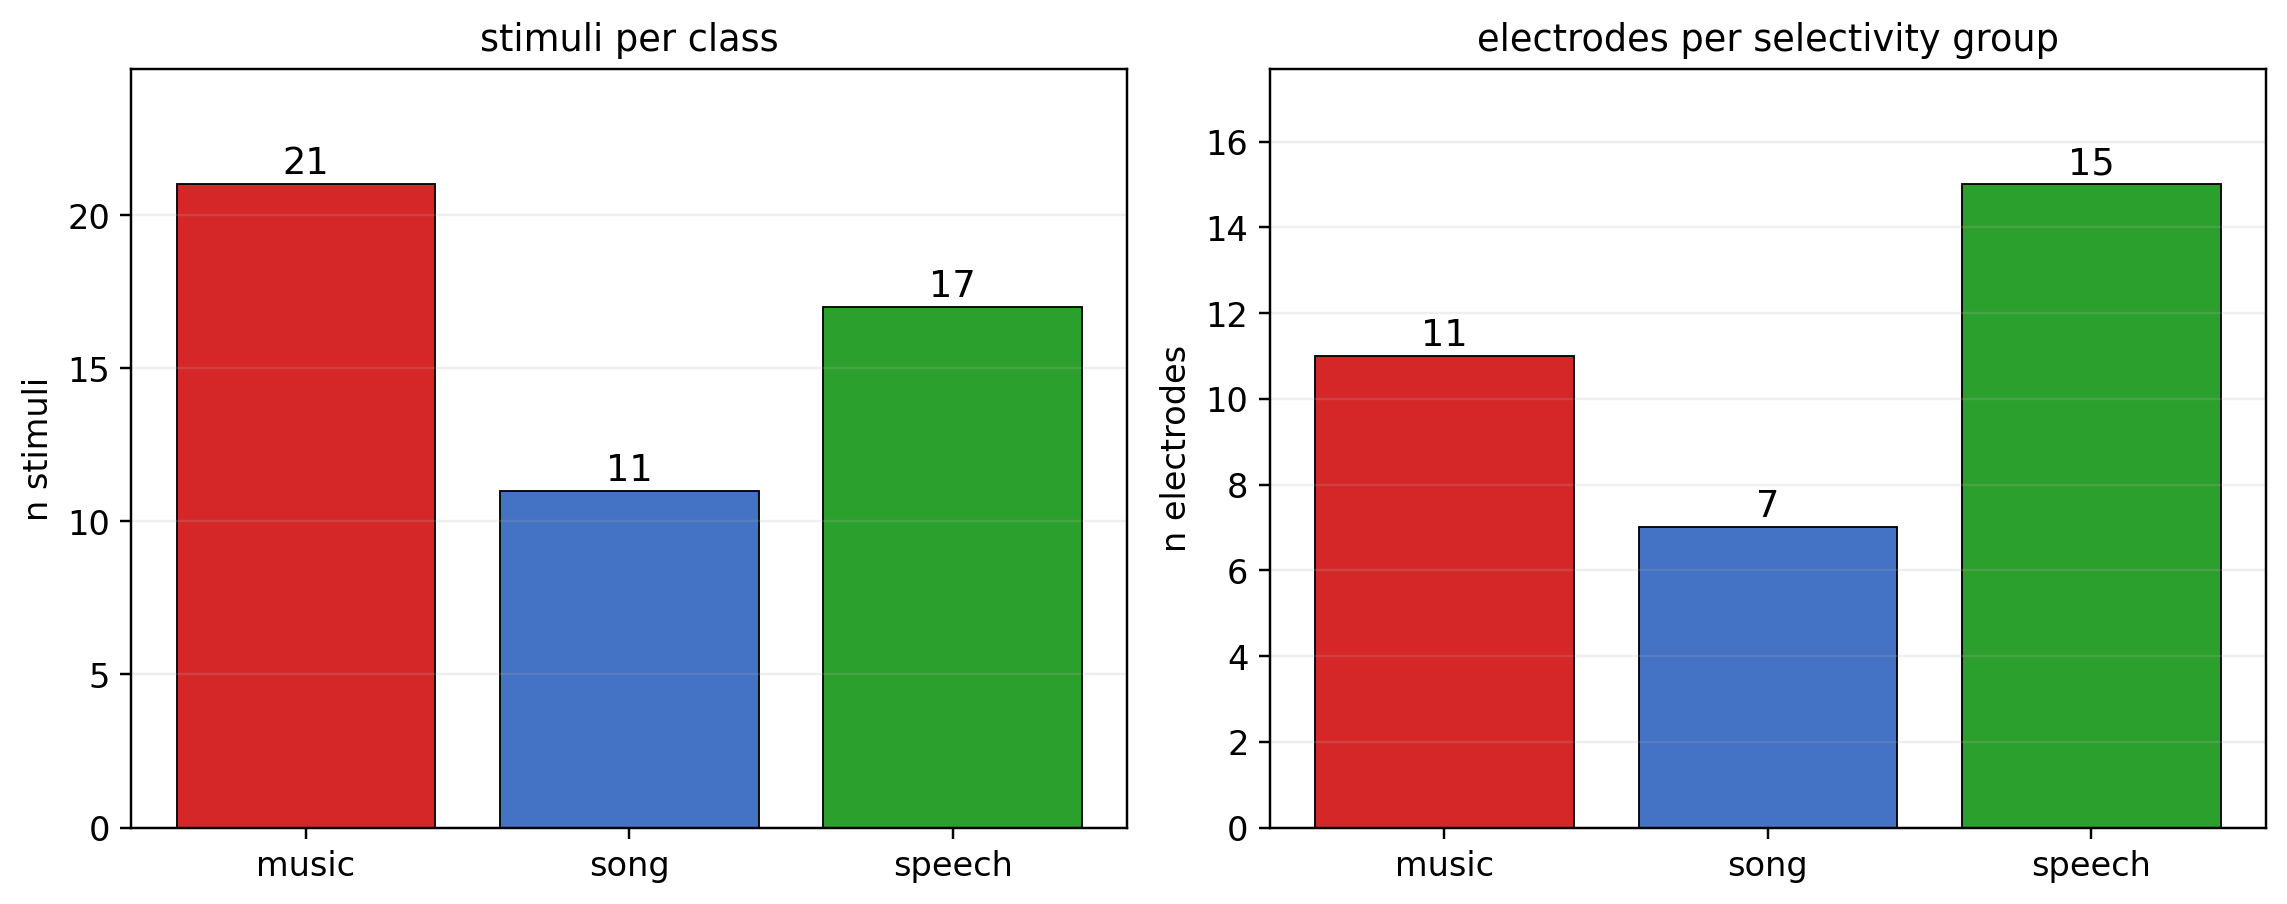

In [16]:
from plots import plot_dataset_overview

plot_dataset_overview(ds["meta"], ds["electrode_group"], ds["y_coarse"])
display(Image(filename=str(FIG_DIR / "fig1_dataset_overview.png")))

## 2) Baseline three-class decoder (Figure 2)

**Question.** Can a standard linear decoder separate the three coarse classes at all?

**What we do.** Logistic regression with stimulus-grouped 5-fold CV on the early-window mean (0.2--0.6 s). Report balanced accuracy and the normalised confusion matrix.

**What to look for.** Balanced accuracy far above chance (1/3) and a diagonal-heavy confusion matrix. Any residual errors should land on the song/music confusion; that confusion is what the rest of the notebook is about.


,task,window_s,balanced_accuracy,macro_f1,recall_music,recall_song,recall_speech
0,three_class,0.2-0.6,0.984127,0.977377,0.952381,1.0,1.0


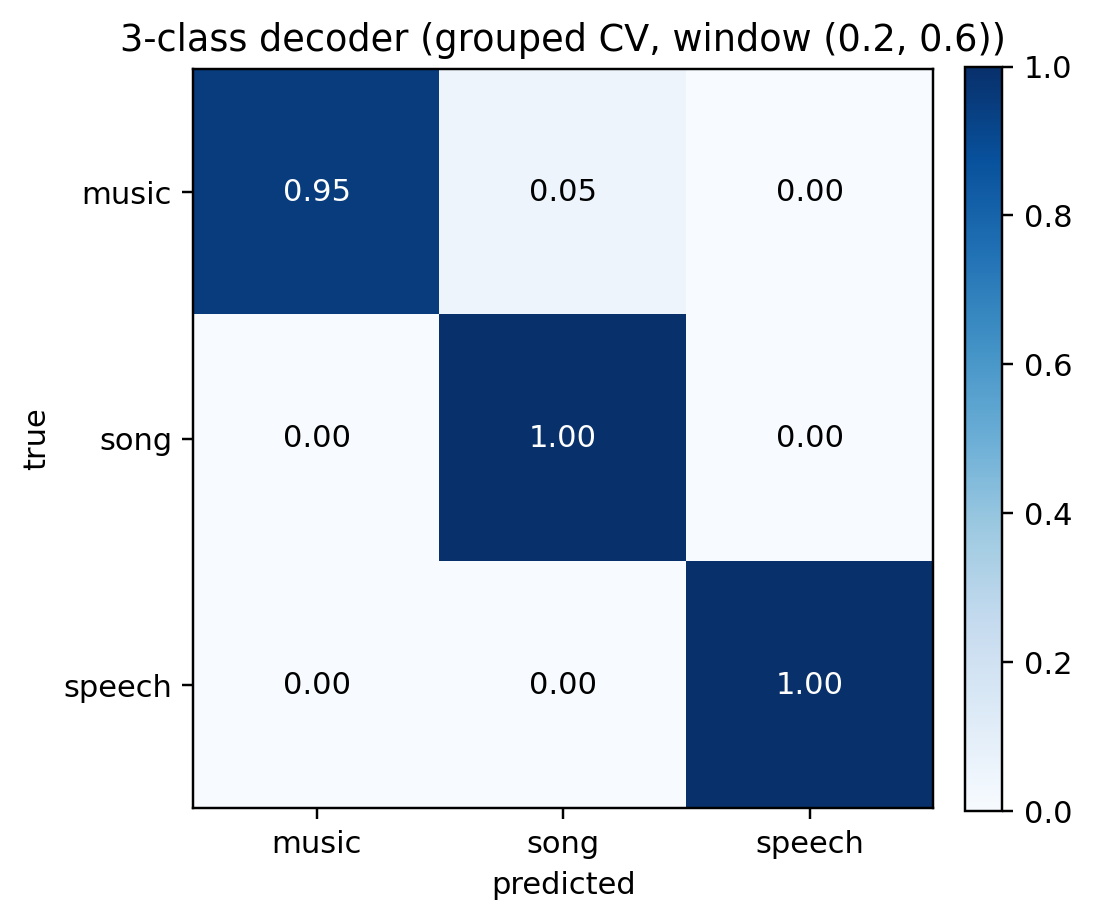

In [3]:
b = pipeline.run_baseline_3class(ds)
display(b["summary"])
display(Image(filename=str(FIG_DIR / "fig2_baseline_confusion.png")))

**Interpretation.** The 3-class decoder is near ceiling and the only residual errors are song/music confusions. The grouped-CV pipeline is working, and coarse category information is easy to read out in the early window. Every later analysis zooms in on the song-vs-music part.


## 3) Time-resolved song-vs-music decoder (Figure 5)

**Question.** When during the 2-second trial is song distinguishable from instrumental music, and which subsets of electrodes can support that distinction?

**What we do.** Sliding-window (150 ms window, 50 ms step) grouped-CV logistic regression on the song-vs-music pair, separately for `all`, `no_song`, and `song_only`. Shaded bands are stimulus-level bootstrap 95% CIs on the held-out predictions.

**What to look for.** Where each curve peaks and how high it goes. If `song_only` looks higher than `no_song` this might mean song-selective electrodes carry more information -- or just that smaller subsets are easier to fit. Section 5 is the fair test.


,subset,peak_bacc,peak_time_s,early_window_mean_bacc,full_window_mean_bacc,mean_auc
0,all,1.000000,0.47,0.927760,0.912110,0.936774
1,no_song,0.954545,0.52,0.884740,0.859592,0.903964
2,song_only,1.000000,0.67,0.881223,0.912964,0.946685


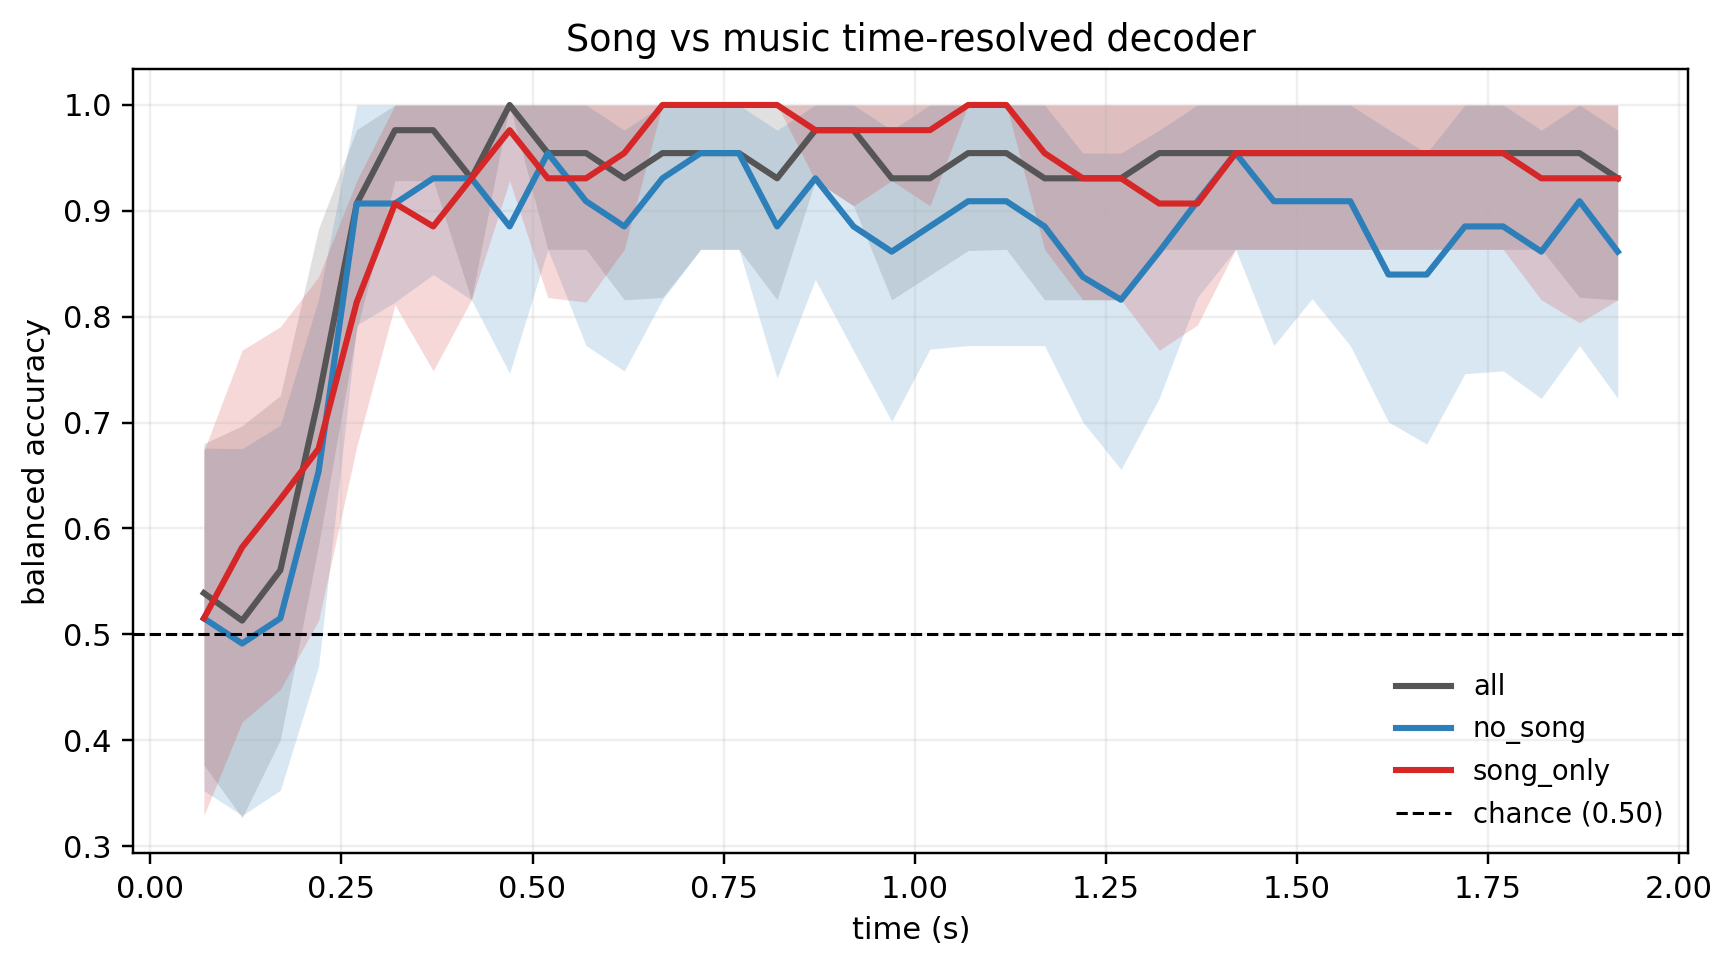

In [5]:
t_out = pipeline.run_time_resolved_songmusic(ds, n_boot=200)
display(t_out["summary"])
display(Image(filename=str(FIG_DIR / "fig5_songmusic_time_curves.png")))

**Interpretation.** All three subsets clearly carry song-vs-music information. `song_only` matches or exceeds `no_song` in the raw curves, which *looks* like specialisation for song coding. Hold that interpretation until we compare against the matched random-subset null in Section 5; small subsets can look artificially good.


## 4) Formalised divergence with bootstrap and permutation (Figure 3)

**Question.** How different are the population responses to song versus music in the representational geometry, independent of any particular classifier?

**What we do.** Compute the RDM divergence

$$\mathcal{D}(a,b) = \text{mean\_between}(a,b) - \tfrac{1}{2}\bigl[\text{mean\_within}(a) + \text{mean\_within}(b)\bigr].$$

For each time window we bootstrap stimuli (95% CI) and build a chance-level band by shuffling song/music labels 1000 times and recomputing divergence. `p_peak` is the one-sided permutation $p$-value at the peak.

**What to look for.** A divergence curve that rises above its own chance-level band means the neural geometry really separates song from music at that time. Compare the three subsets' peak locations and heights; as in Section 3, a bigger `song_only` peak is confounded with subset size and is addressed fairly in Section 5.


,subset,peak_divergence,peak_time_s,early_window_mean,boot_ci_lo_at_peak,boot_ci_hi_at_peak,p_peak_permutation
0,all,0.215230,1.72,0.167111,0.036404,0.201169,0.000999
1,no_song,0.108410,0.27,0.048663,0.149774,0.346254,0.004995
2,song_only,0.408296,0.37,0.299040,0.092353,0.394972,0.001998


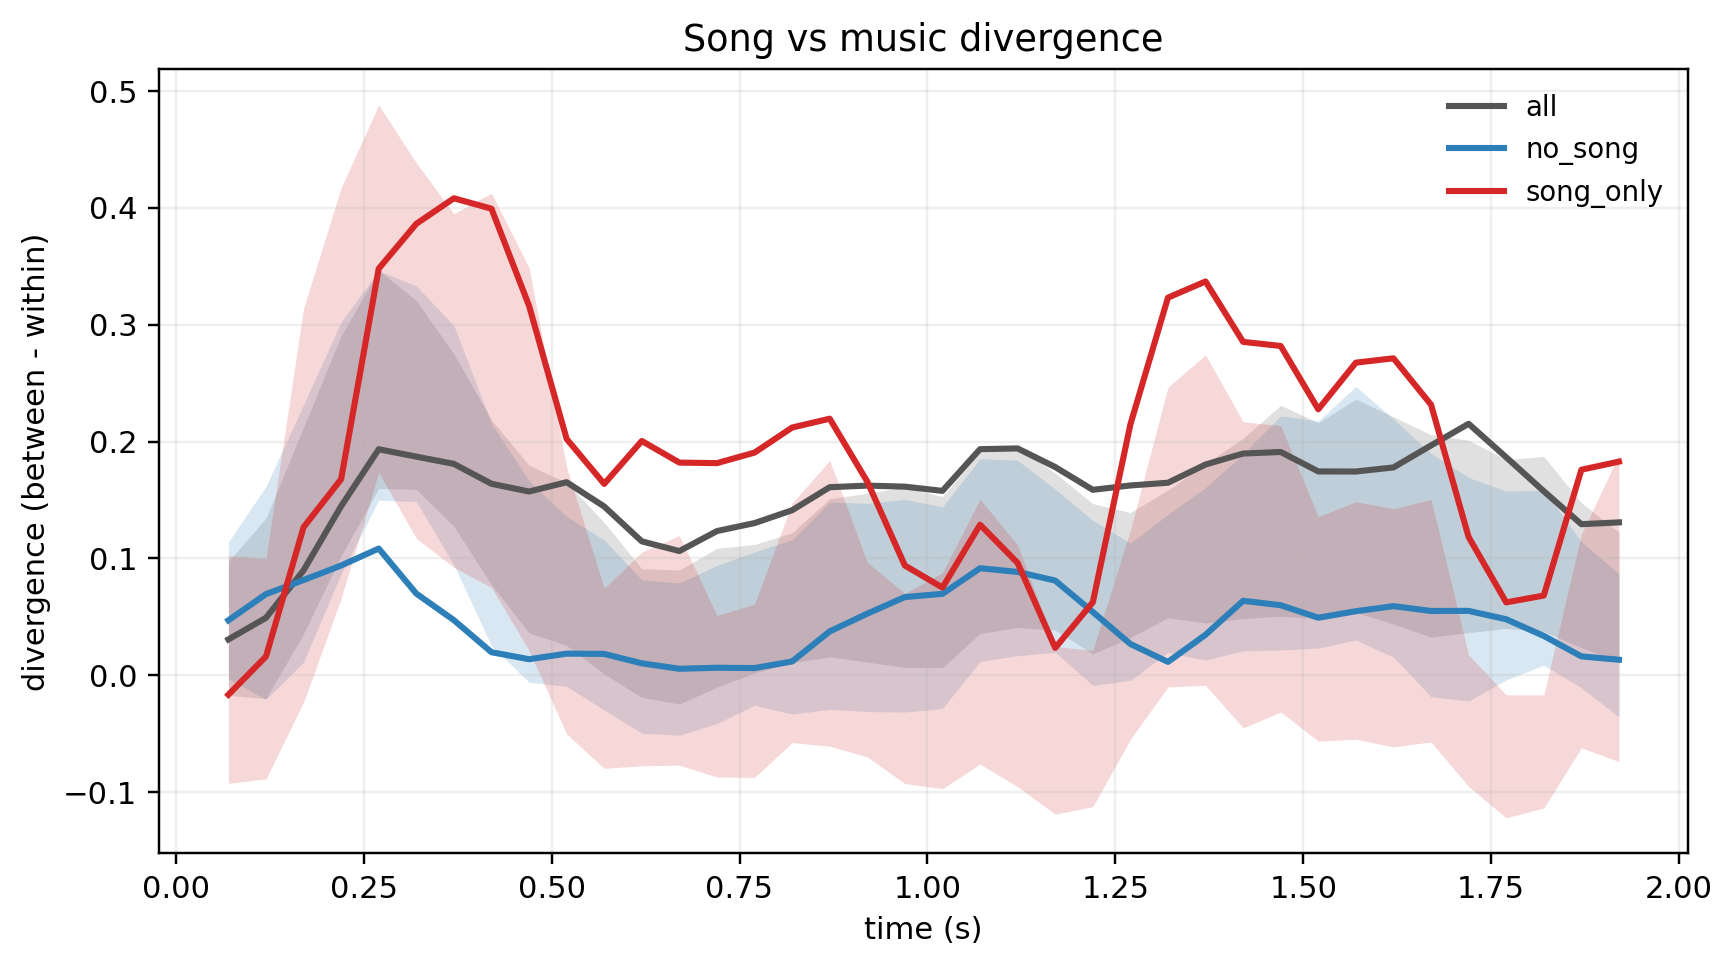

In [18]:
d = pipeline.run_formalized_divergence(ds)
display(d["summary"])
display(Image(filename=str(FIG_DIR / "fig3_divergence_combined.png")))

**Interpretation.** All three subsets rise well above their chance-level band ($p_\text{peak} < 0.005$), so the neural geometry of song vs. music is real in all of them. `song_only` has the largest peak but also the noisiest curve (only 7 electrodes). Whether that peak difference reflects true specialisation or a small-subset effect is what the matched random-subset control tests next.


## 4b) Acoustic-partialled divergence (mechanistic control)

**Question.** How much of the song-vs-music signal in the neural geometry is just low-level acoustics, and how much survives after those are controlled for?

**What we do.** For each sliding window, regress the stimulus-level cochleogram (`F_coch`, 6 features) and spectrotemporal-modulation (`F_mod`, 7$\times$9 = 63 features) bank out of the neural features, then recompute divergence on the residuals. Both raw and partialled curves are tested against a label-shuffle chance band; for the partialled curve we redo the acoustic regression inside every shuffle so the null also reflects the residual geometry.

**What to look for.** The `fraction_surviving_at_peak` column tells us how much of the raw peak remains after partialling. Near 1 means almost none of the signal is explained by the acoustic bank (strong non-acoustic structure); near 0 means the signal is essentially acoustic. A borderline $p$-value on the partialled curve means the remaining structure is real but at the edge of what this sample size can detect.


In [7]:
import importlib, rdm, pipeline, data_utils
importlib.reload(data_utils); importlib.reload(rdm); importlib.reload(pipeline)

ap = pipeline.run_acoustic_partition(ds, n_perm=1000, ridge=1.0)
display(ap['summary'])
for name, figs in ap['figures'].items():
    print(name, '->', figs['png'].name)

  [acoustic partition] regressor 'A_full' shape=(49, 69) ridge=1.0


KeyboardInterrupt: 

**Interpretation.** The raw divergence reflects everything that separates song from music, including purely acoustic differences (harmonicity, timbre, modulation rates). The partialled curve estimates what remains after subtracting out what the Norman--Haignere acoustic bank can linearly predict. A surviving fraction well above zero with a near-significant permutation $p$ means some structure remains, but at this sample size and with this specific acoustic bank we should describe it as a suggestive residual, not a clean "post-acoustic code."


## 5) Matched random-subset control (Figure 4, headline)

**Question.** Do the 7 song-selective electrodes actually carry more song-vs-music information than any other 7 electrodes would?

**What we do.** Compare the `song_only` score against 1000 random 7-electrode draws from the non-song pool. We run this for two metrics:

1. **Balanced accuracy** on the song-vs-music early-window feature (model-based).
2. **RDM divergence** on the same feature (representational).

For each metric we report the true `song_only` value, the null mean and spread, a one-sided empirical $p$-value, and a bootstrap CI for `true - mean(null)`.

**What to look for.** A small $p$ (and a CI for `true - mean(null)` that is clearly above zero) means song-selective electrodes beat size-matched random comparisons. A large $p$ means they do not, and any "song-only looks great" appearance from Sections 3 and 4 is explained by the fact that small subsets are easier to fit than large ones.


,metric,task,subset_size,n_random_subsets,true_song_only,null_mean,null_std,null_median,ref_all,ref_no_song,p_greater_vs_random,diff_ci_lo,diff_ci_median,diff_ci_hi
0,bacc,song_vs_music,7,10,0.839827,0.850433,0.044480,0.861472,0.954545,0.885281,0.818182,-0.035720,-0.011255,0.017316
1,divergence,song_vs_music,7,10,0.235823,0.168967,0.133577,0.135048,0.239878,0.212349,0.363636,-0.019131,0.067819,0.142320


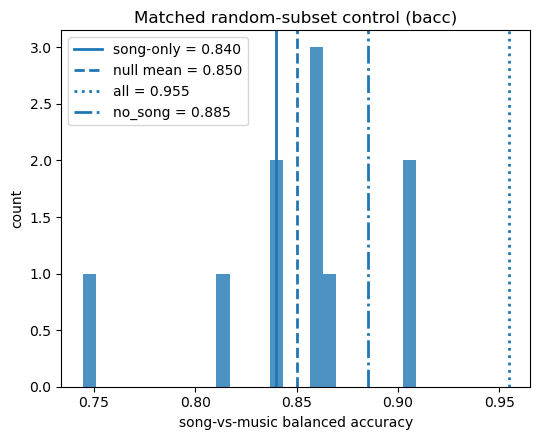

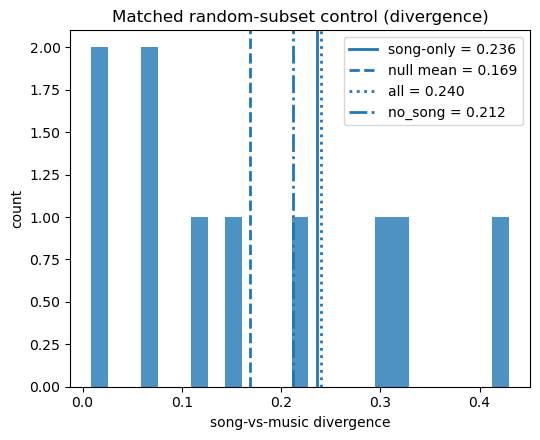

In [13]:
import matplotlib.pyplot as plt
import numpy as np

r = pipeline.run_random_subset_control(ds, n_subsets =10)
display(r["summary"])

#for m in ("bacc", "divergence"):
 #   print(f"--- metric: {m} ---")
 #   display(Image(filename=str(FIG_DIR / f"fig4_random_subset_null_{m}.png"),width=400))

for m in ("bacc", "divergence"):
    res = r["by_metric"][m]

    fig, ax = plt.subplots(figsize=(5.5, 4.5))  # change ratio here

    ax.hist(res["null_scores"], bins=25, alpha=0.8)

    ax.axvline(res["true_score"], linewidth=2, label=f"song-only = {res['true_score']:.3f}")
    ax.axvline(np.mean(res["null_scores"]), linestyle="--", linewidth=2,
               label=f"null mean = {np.mean(res['null_scores']):.3f}")
    ax.axvline(res["reference_scores"]["all"], linestyle=":", linewidth=2,
               label=f"all = {res['reference_scores']['all']:.3f}")
    ax.axvline(res["reference_scores"]["no_song"], linestyle="-.", linewidth=2,
               label=f"no_song = {res['reference_scores']['no_song']:.3f}")

    ax.set_title(f"Matched random-subset control ({m})")
    ax.set_xlabel("song-vs-music balanced accuracy" if m == "bacc" else "song-vs-music divergence")
    ax.set_ylabel("count")
    ax.legend()
    plt.tight_layout()
    plt.show()

**Interpretation - balanced accuracy.** The `song_only` score sits well inside the random-draw distribution (see summary table). The bootstrap CI for `song_only - mean(null)` is small and close to zero, so on this metric song electrodes do not beat random 7-electrode draws from the non-song pool. This is the central negative result of the project: the raw advantage of `song_only` over `all` in Section 3 is a subset-size effect, not a sign of song-selectivity.

**Interpretation - divergence.** On divergence the true-minus-null CI is slightly positive, but the empirical $p$ does not clear 5%. So there is at most a small per-electrode advantage in representational geometry, and it is not significant against matched random subsets.

**Takeaway.** Song-selective electrodes are informative but not privileged. The stronger claim "song-only carries song-vs-music information that other 7-electrode subsets cannot" is not supported by this control.


## 6) Cross-temporal generalisation (Figure 6)

**Question.** Is the song-vs-music code the same throughout the trial, or does it change over time?

**What we do.** Train a decoder at time $t_i$ and test at every other time $t_j$. Stack all $(t_i, t_j)$ pairs into an $N_t \times N_t$ balanced-accuracy matrix per subset.

**What to look for.** Bright off-diagonals mean a stable code (a decoder trained early still works late). Dark off-diagonals mean the code drifts. For a single number, we compare the diagonal mean to the mean of off-diagonal entries at least 0.25 s apart (a buffer wider than the sliding window, so the two means aren't measuring the same window).


,subset,diag_mean_bacc,offdiag_mean_bacc,max_bacc
0,all,0.912110,0.839800,1.0
1,no_song,0.859592,0.754786,1.0
2,song_only,0.912964,0.832701,1.0


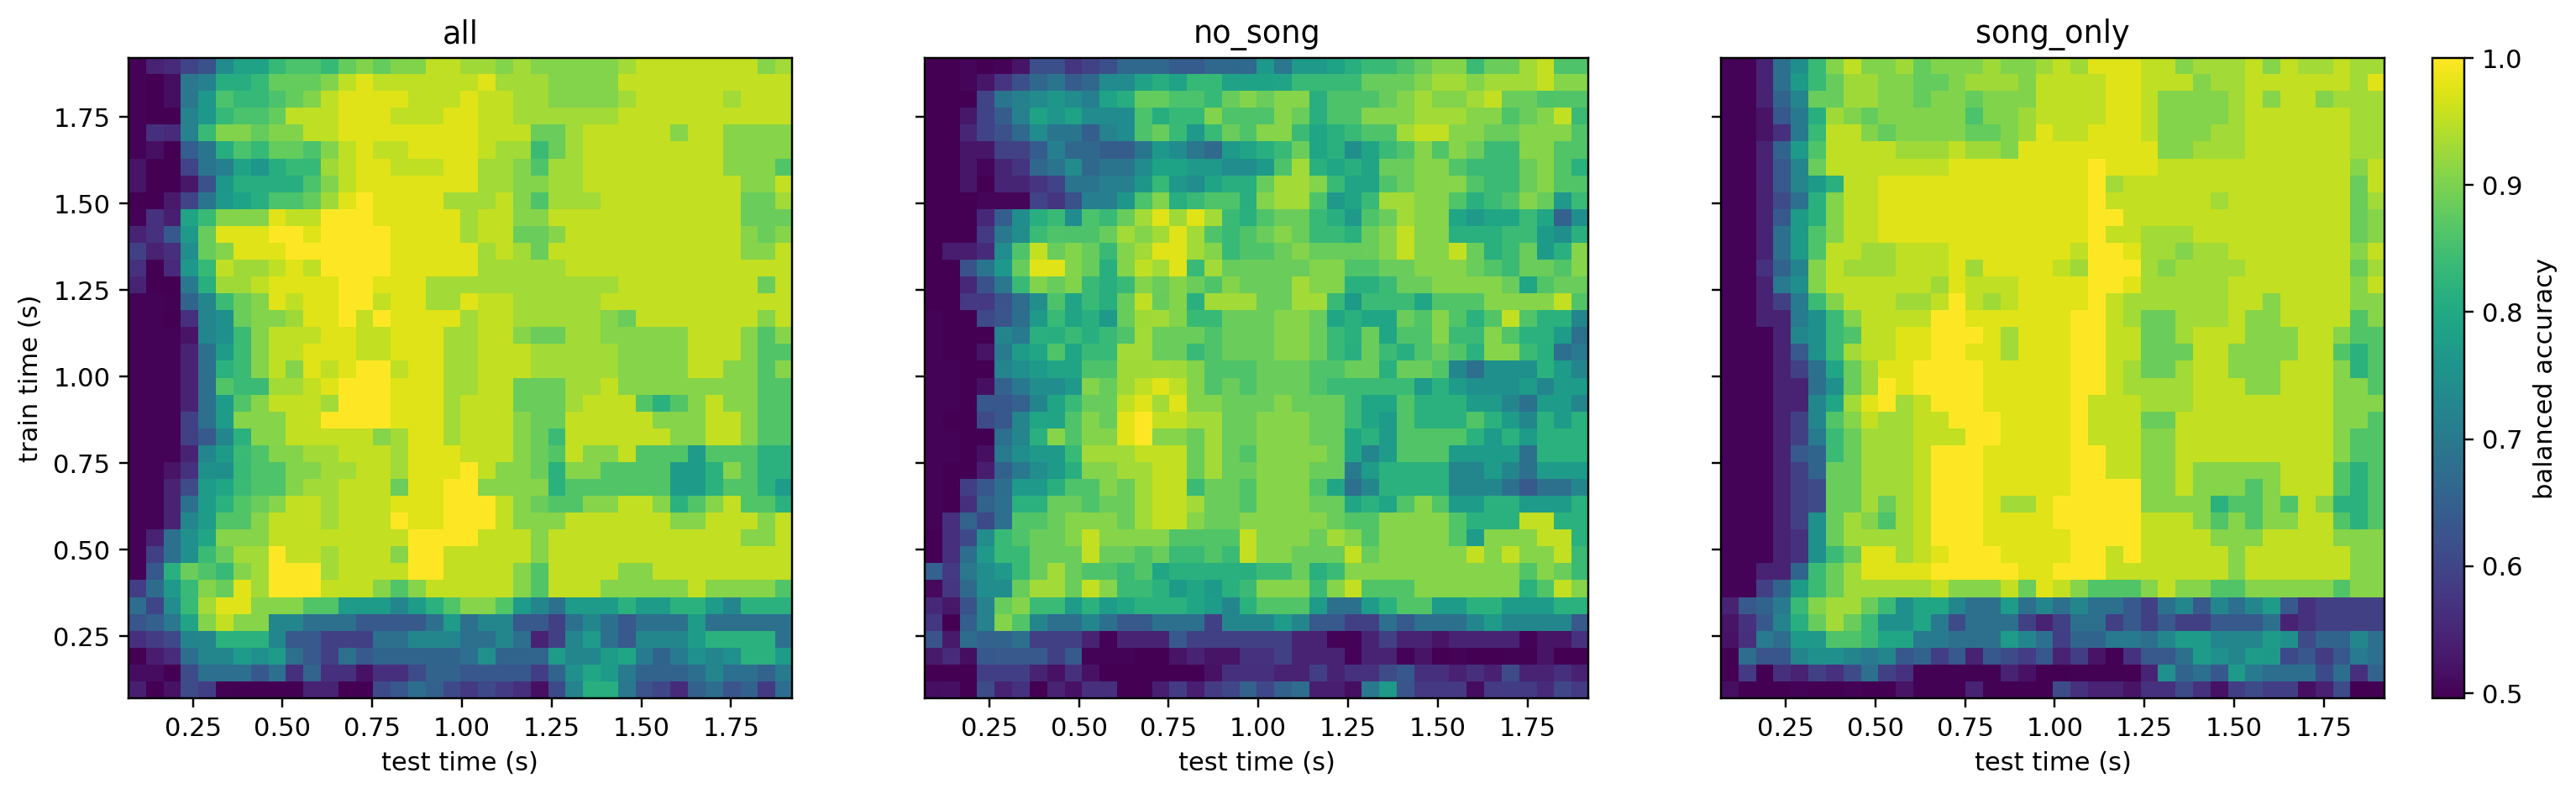

In [9]:
c = pipeline.run_cross_temporal(ds)
display(c["summary"])
display(Image(filename=str(FIG_DIR / "fig6_cross_temporal.png")))

**Interpretation.** Every subset has a bright diagonal, as expected. The more interesting part is the off-diagonal: for `song_only` and `all` a classifier trained early still works late, while for `no_song` it decays faster. The song-vs-music code in the song-selective subset is more temporally stable than in the non-song pool, even though the two are indistinguishable on raw decodability.


## 7) Leave-one-electrode-out contributions (Figure 7)

**Question.** Which individual electrodes carry the song-vs-music signal, and do song-selective electrodes contribute more per electrode than non-song ones?

**What we do.** Drop one electrode at a time, rerun time-resolved song-vs-music decoding and divergence, and record how much the score drops. Group the per-electrode drops by selectivity (song / speech / music) and test whether the song group has a larger mean drop than the non-song group with a 1000-shuffle permutation.

**What to look for.** A positive group effect for song electrodes on balanced accuracy would mean song electrodes each carry a little more of the decoder's signal than speech or music electrodes do. On divergence, the picture can differ, which is informative.


,electrode_group,mean_delta_bacc,std_delta_bacc,mean_delta_divergence,n,perm_p_song_vs_rest_bacc
0,music,0.003024,0.002648,0.004899,11,0.013986
1,song,0.005322,0.004138,0.001667,7,0.013986
2,speech,0.002001,0.002348,-0.003893,15,0.013986


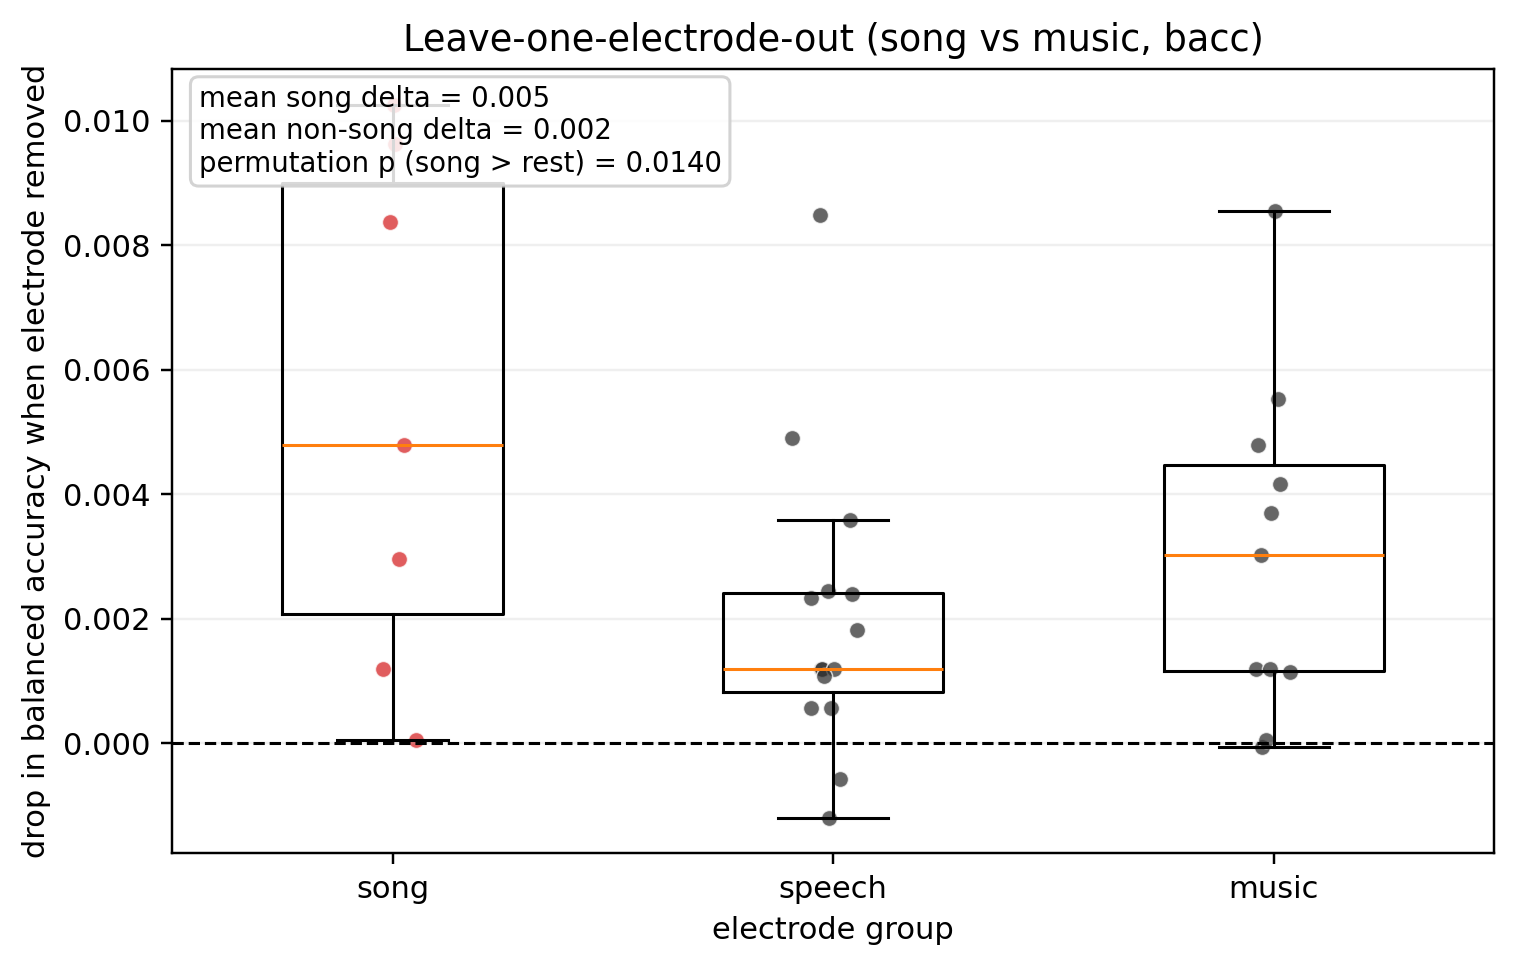

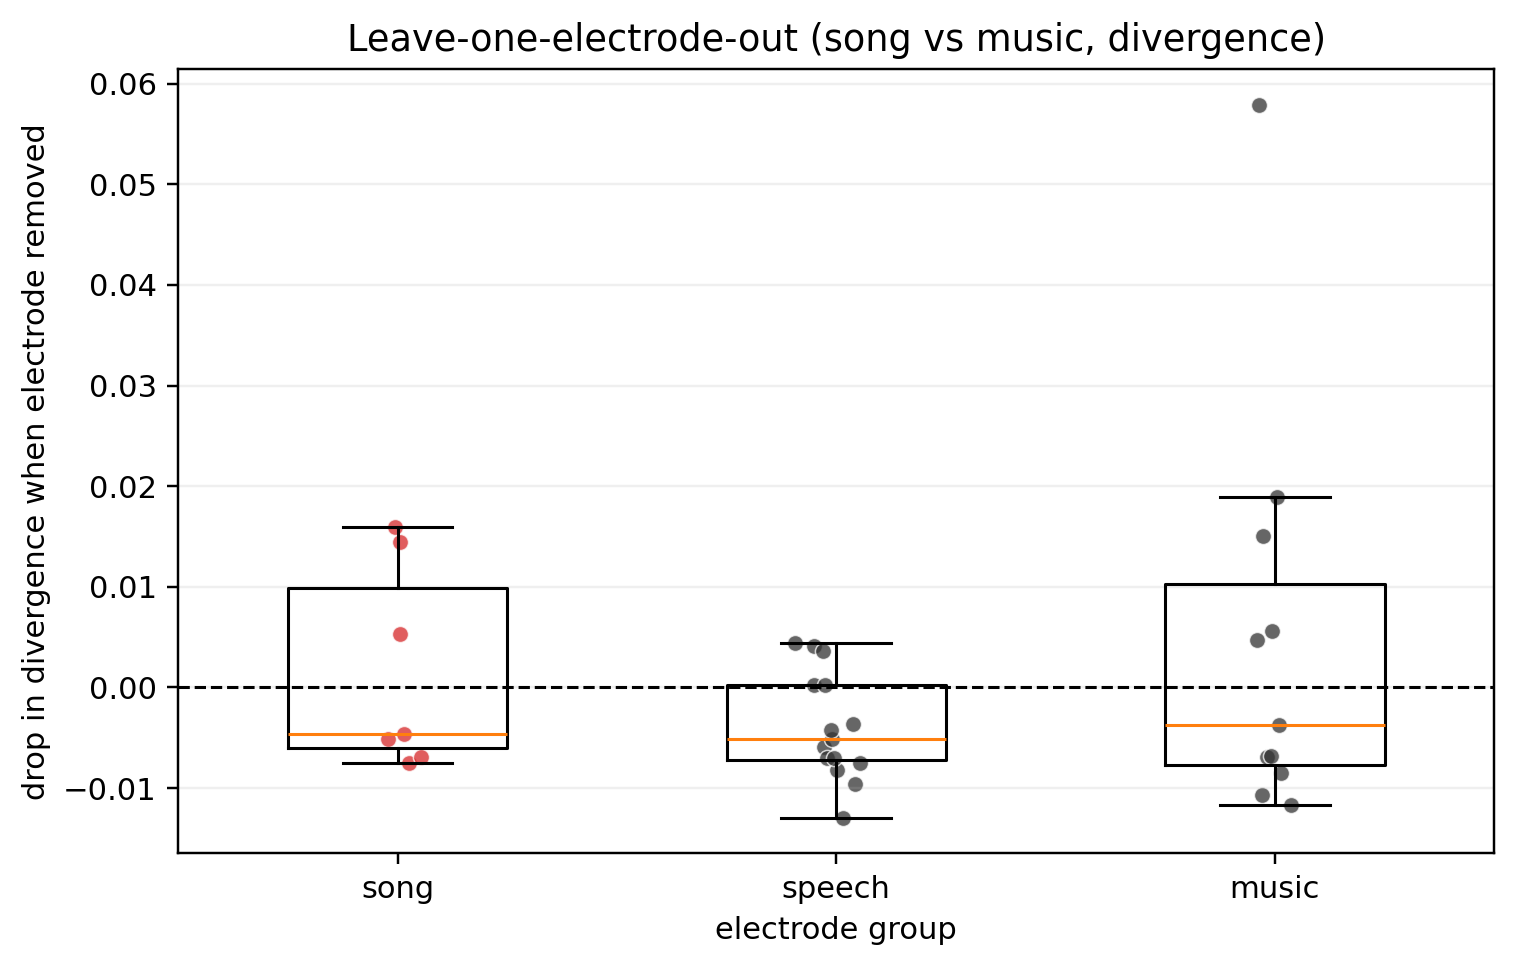

In [10]:
l = pipeline.run_loo_clean(ds, n_perm=1000)
display(l["group_summary"])
display(Image(filename=str(FIG_DIR / "fig7_loo_contributions_bacc.png")))
display(Image(filename=str(FIG_DIR / "fig7_loo_contributions_divergence.png")))

**Interpretation.** On time-resolved balanced accuracy, song electrodes contribute the most per electrode on average, and the song-vs-non-song group difference is significant (see summary). On divergence the picture is different: no group dominates. Taken with Section 5, the overall message is: song electrodes are not a uniquely privileged *group* on raw decodability, but each one tends to pull a little more weight than an individual non-song electrode.


## 8) Supplement: nonlinear baselines (negative result)

**Question.** Could a nonlinear model extract more song-vs-music information than logistic regression, and would song-selective electrodes then look special?

**What we do.** Run an RBF-kernel SVM and a frozen autoencoder + logistic regression on the same stimulus-grouped folds, on the same early-window feature, for both the 3-class and the song-vs-music tasks.

**What to look for.** If the nonlinear models beat the linear baseline, the linear analyses might miss song-specific structure. If they don't, the linear decoder is already near the ceiling of what the data supports.


,task,model,bacc,macro_f1,fold_bacc_std,recall_music,recall_song,recall_speech
0,song_vs_music_all_electrodes,autoencoder_latent_logreg,0.954545,0.964563,0.100000,1.000000,0.909091,NaN
1,song_vs_music_all_electrodes,linear_logreg,0.954545,0.964563,0.100000,1.000000,0.909091,NaN
2,song_vs_music_all_electrodes,rbf_svm,0.954545,0.964563,0.100000,1.000000,0.909091,NaN
3,three_class_all_electrodes,autoencoder_latent_logreg,0.893218,0.898942,0.114396,0.952381,0.727273,1.0
4,three_class_all_electrodes,linear_logreg,0.984127,0.977377,0.022222,0.952381,1.000000,1.0
5,three_class_all_electrodes,rbf_svm,0.953824,0.953824,0.129577,0.952381,0.909091,1.0


,task,model,delta_bacc_vs_linear
0,song_vs_music_all_electrodes,autoencoder_latent_logreg,0.000000
1,song_vs_music_all_electrodes,rbf_svm,0.000000
2,three_class_all_electrodes,autoencoder_latent_logreg,-0.090909
3,three_class_all_electrodes,rbf_svm,-0.030303


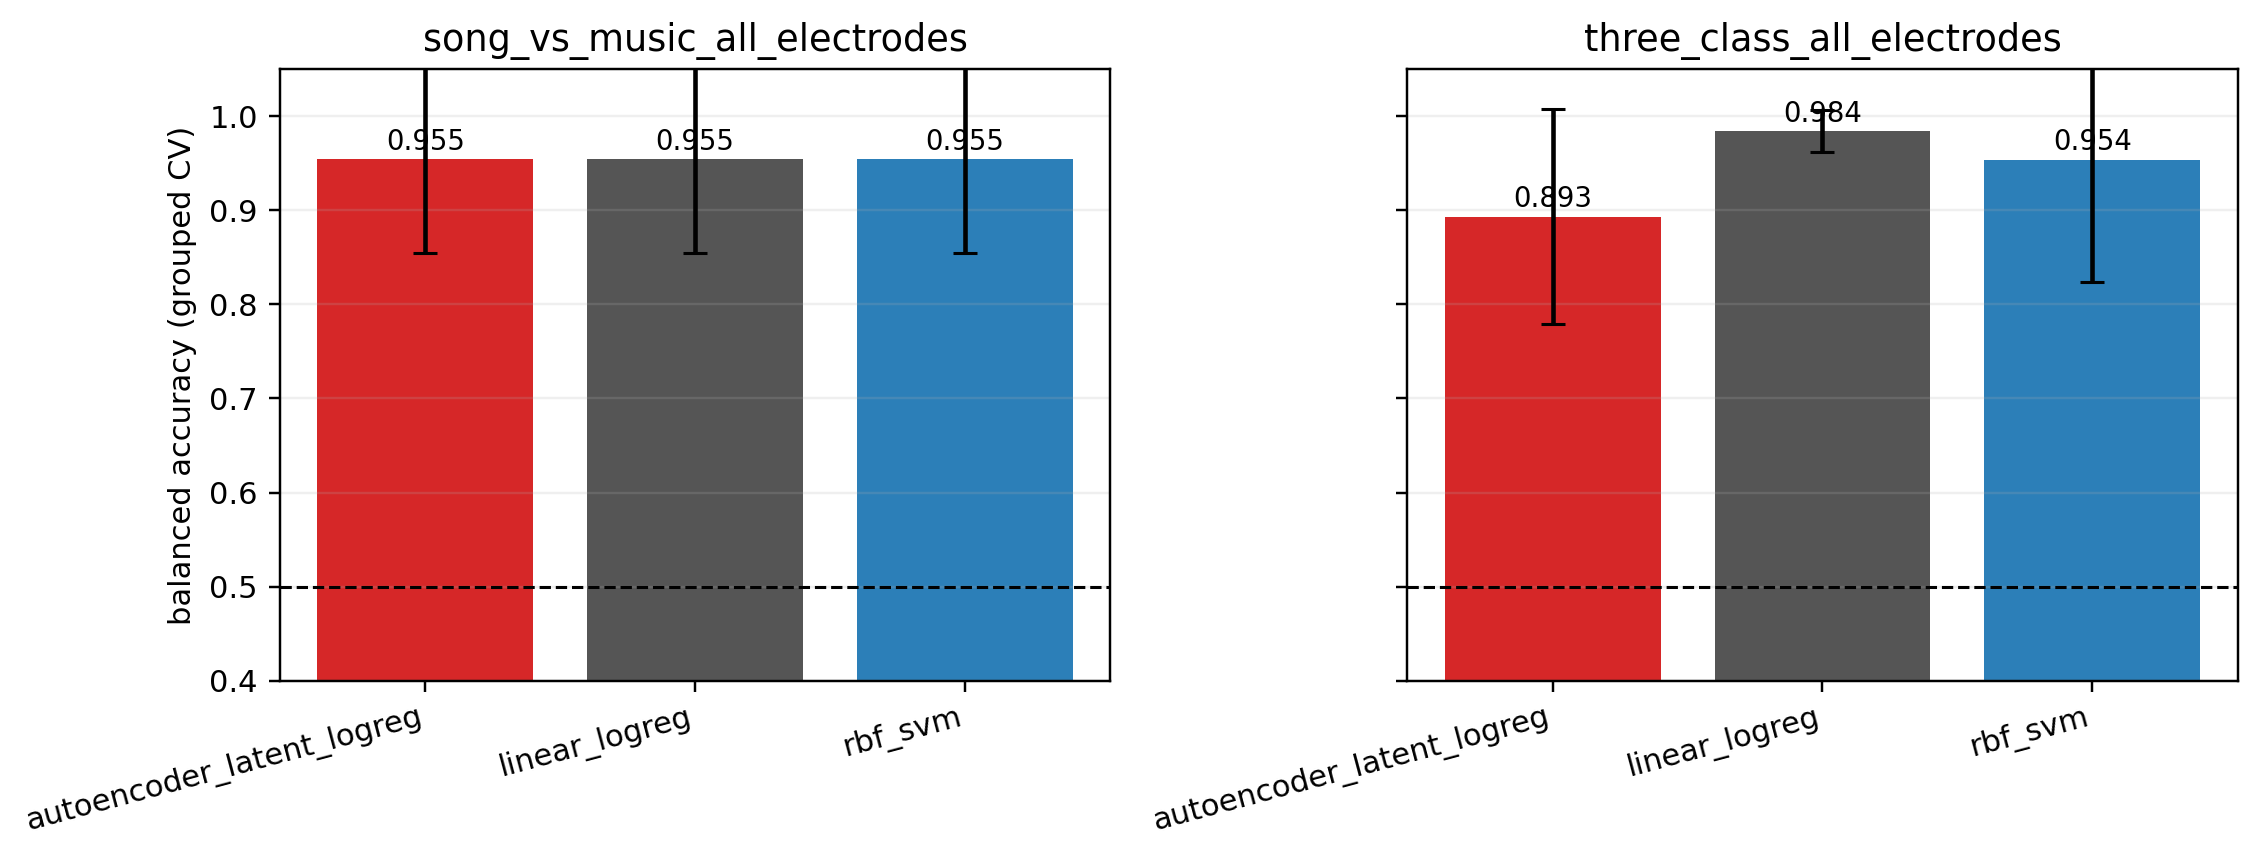

In [11]:
nl = pipeline.run_nonlinear_supplement(ds)
display(nl["summary"])
display(nl["delta_vs_linear"])
display(Image(filename=str(FIG_DIR / "fig_nonlinear_comparison.png")))

**Interpretation.** Neither nonlinear model beats logistic regression on this data. Linear decoding is already saturating the signal, which is expected at $N$ = 49 stimuli. This justifies using the linear decoder throughout the rest of the paper.


## 9) Extension 1 - Bellier (2023) vocal-vs-instrumental decoder (Figure 8)

**Question.** Does the same kind of decoding analysis transfer from Norman--Haignere's controlled 2-second clips to naturalistic continuous music?

**What we do.** Pool the HFA of 2,395 electrodes from 29 patients in Bellier (2023) into a *supergrid* ($T$ = 19{,}072 samples at 100 Hz = 190.72 s of Pink Floyd's *Another Brick in the Wall, Part 1*). Slide 500-ms windows every 100 ms, label each window `vocal` if more than 50% of its samples fall inside the hand-annotated vocal mask, and run 5-fold blocked-time logistic regression. A small temporal CNN runs only on subsets where logreg clears chance by $\geq 0.05$ bacc.

### Stimulus and vocal-mask bookkeeping

- **Audio.** `data/bellier_2023/audio/thewall1.wav` is the exact clip used during the recordings (190.72 s, 44.1 kHz). After downsampling to 100 Hz it aligns exactly with the neural data, so annotation time = real song time.
- **Vocal annotation.** `data/bellier_2023/audio/vocal_segments.csv` is a manual annotation of when the lead vocal is present (rows `start_s,end_s`). Overlaps are union-merged.

**What to look for.** The expected anatomical ordering from Bellier (2023) is `right_STG > left_STG > non_STG`. If `all` also comes out high, the signal is distributed rather than locked to STG.


**Sanity check: stimulus alignment and vocal-mask coverage.** Before running the decoder, verify that the WAV duration matches the neural time axis (no resampling needed) and that the parsed vocal intervals look right.


In [10]:
import wave
import numpy as np
from bellier_data import load_vocal_segments
from config import BELLIER_AUDIO_PATH, BELLIER_FS, BELLIER_T, BELLIER_VOCAL_CSV

with wave.open(str(BELLIER_AUDIO_PATH), 'rb') as w:
    wav_dur = w.getnframes() / w.getframerate()
neural_dur = BELLIER_T / BELLIER_FS
print(f'WAV duration    : {wav_dur:.3f} s ({BELLIER_AUDIO_PATH.name})')
print(f'Neural duration : {neural_dur:.3f} s (T={BELLIER_T} @ {BELLIER_FS} Hz)')
print(f'Aligned         : {np.isclose(wav_dur, neural_dur, atol=0.01)} '
      f'-> no time-stretching, annotations are in real song time')

mask = load_vocal_segments()
diff = np.diff(mask.astype(int))
starts = np.where(diff == 1)[0] + 1
ends = np.where(diff == -1)[0] + 1
if mask[0]:  starts = np.r_[0, starts]
if mask[-1]: ends = np.r_[ends, len(mask)]
print(f'\nVocal CSV        : {BELLIER_VOCAL_CSV.name}')
print(f'Vocal samples    : {int(mask.sum())} / {len(mask)}  '
      f'({mask.mean()*100:.2f}%)')
print(f'Merged intervals : {len(starts)}')
for s, e in zip(starts, ends):
    print(f'  {s/BELLIER_FS:7.3f} - {e/BELLIER_FS:7.3f}  '
          f'({(e-s)/BELLIER_FS:.3f}s)')

WAV duration    : 190.720 s (thewall1.wav)
Neural duration : 190.720 s (T=19072 @ 100 Hz)
Aligned         : True -> no time-stretching, annotations are in real song time

Vocal CSV        : vocal_segments.csv
Vocal samples    : 5803 / 19072  (30.43%)
Merged intervals : 4
   15.080 -  16.900  (1.820s)
   17.460 -  19.150  (1.690s)
   24.410 -  29.570  (5.160s)
   42.660 -  92.020  (49.360s)


In [13]:
bd = pipeline.run_bellier_decoder()
display(bd['summary'])

  [decoder] subset=all        n_elec= 2395 n_wins= 1903 pos_rate=0.304
    logreg  bacc=0.777 CI=[0.733, 0.775]
    cnn     bacc=0.765 CI=[0.724, 0.766] (n_elec_in=256)
  [decoder] subset=right_STG  n_elec=  181 n_wins= 1903 pos_rate=0.304
    logreg  bacc=0.692 CI=[0.655, 0.696]



KeyboardInterrupt



**Interpretation.** Read the summary table against the expected right-STG > left-STG > non-STG ordering.

- If `right_STG` comes out highest, this is consistent with Bellier (2023)'s right-hemisphere vocal bias, on an independent decoding target (vocal presence) and a blocked linear decoder.
- If `all` matches or exceeds the STG subsets, the vocal signal is distributed and STG is not privileged at the population level.
- If `non_STG` stays near chance while STG clears it, that is converging evidence that vocal/instrumental coding in this song lives in higher-order auditory cortex.

The CNN row is informative only if it clears chance and beats logreg; a small or no CNN gain on top of logreg on mean HFA is the expected outcome, not a failure.


## 10) Extension 2 - Cross-dataset temporal profiles (Figures 9-10)

**Question.** Do the song-selective electrodes in Norman--Haignere look like the right-STG vocal responses in Bellier in terms of response *shape* over time?

**What we do.** Extract HFA profiles from both datasets in a shared format. For Bellier: average across electrodes in a group and lock to vocal or instrumental onsets. For Norman--Haignere: average across electrodes in each selectivity group and across stimuli in each class, using the trial-aligned time axis. For each profile we compute:

- `peak_latency_s` -- time of the maximum within [0, 1.0] s.
- `onset_sustained_ratio` -- mean HFA in [0, 0.2] s divided by mean HFA in [0.5, 1.5] s. Below 1 is sustained; above 1 is transient.
- `auc` -- trapezoid integral of HFA in [0, 1.5] s (within-dataset only, since amplitude scales differ).

Figure 10 overlays peak-normalised Bellier right-STG (vocal onsets) and Norman song-electrodes (song trials). The comparison is qualitative, not a test; we look at whether the two shapes match.


In [ ]:
import importlib, temporal_profile, pipeline
importlib.reload(temporal_profile)
importlib.reload(pipeline)

bp = pipeline.run_bellier_profiles(ds_norman=ds)
display(bp['combined_features'])

**Interpretation.** The `onset_sustained_ratio` is the most informative column. If Bellier `right_STG__vocal` and Norman `song__song` both have a ratio below 1 (sustained) with similar shape, that is consistent with Norman song-selectivity reflecting the same sustained vocal-tracking component Bellier describes at the scale of a full song. If instead Norman song electrodes look more transient than Bellier right-STG, the two datasets are tracking different temporal regimes, and that is also an honest, reportable result. The overlay and the feature table are the entire deliverable for this extension -- it is a shape comparison, not a statistical test.


10.5) Extension 3 - run first paper's pipeline on the new data to see if we find song selective component

In [12]:
import sys
print(sys.executable)

/opt/anaconda3/bin/python


In [7]:
bellier_out = pipeline.run_bellier_vocal_component_model(
    supergrid=supergrid,
    vocal_present=vocal_present,
    K=10,
    activation_penalty=0.01,
    window_size=50,   # 500 ms at 100 Hz
    step_size=50,     # non-overlapping windows
    n_perm=1000,
    seed=0,
)
bellier_out['component_stats']['best_component']
bellier_out['component_stats']['diff']
bellier_out['component_stats']['p']
bellier_out['top_electrodes']

NameError: name 'train_simple' is not defined

## 11) Final takeaways

Read the numbers from the summary tables and figures above; below is the plain-English summary of what those numbers say.

- **Pipeline is clean.** Grouped-CV 3-class decoding is near ceiling in the early window; song-vs-music decoders peak at or near 1.0 balanced accuracy for every subset.
- **Divergence is real.** All three subsets clear their own label-shuffle chance band ($p_\text{peak} < 0.005$), so the song-vs-music geometry is not a labelling artefact.
- **Central negative result.** Under a fair, size-matched comparison, `song_only` does not beat random 7-electrode draws from the non-song pool on balanced accuracy, and only a small non-significant trend on divergence. The "song-only beats all-electrodes" appearance in the raw curves is a subset-size effect.
- **Some structure survives acoustic partialling.** Roughly one-third of the song-vs-music divergence peak remains after regressing out cochleogram and spectrotemporal-modulation features, but the permutation $p$ on the residual is borderline ($\approx 0.05$--0.4 across subsets), so we describe this as a suggestive non-acoustic residual rather than a robust post-acoustic code.
- **Per-electrode contribution.** Leave-one-out on time-resolved balanced accuracy does show that individual song electrodes each pull a little more weight than individual non-song electrodes, even though the group as a whole is not privileged.
- **Stability over time.** Cross-temporal generalisation is more stable in `song_only` and `all` than in `no_song`, consistent with a sustained rather than purely onset-driven code in song-selective electrodes.
- **Nonlinear models don't help.** RBF-SVM and an autoencoder + logreg do not beat logistic regression on grouped CV.
- **Bellier extension (decoder).** Blocked-time logistic regression on the 29-patient supergrid separates vocal from instrumental windows well above chance, with a right-STG > left-STG ordering consistent with Bellier (2023).
- **Bellier extension (profiles).** Event-locked Bellier right-STG responses look more transient than Norman song-electrode trial-locked responses, which are strongly sustained. The two datasets emphasise different parts of the response.

**Most defensible conclusion.** Song-selective electrodes are informative but not privileged. They carry a more temporally stable representation than the non-song pool and each electrode pulls slightly more weight, but as a group of 7 they are indistinguishable from size-matched random non-song subsets on the information a decoder can extract.

All numeric results, seeds, bootstrap samples, and permutation distributions are cached under `results/` and summarised in `results/metrics.json`. Re-run this notebook top-to-bottom to regenerate everything.
